In [17]:
#install pandas
%pip install pandas
#install numpy
%pip install numpy
#install matplotlib
%pip install matplotlib
#install seaborn
%pip install seaborn
#install requests
%pip install requests
#install tqdm
%pip install tqdm
#install geopandas
%pip install geopandas
#install contextily
%pip install contextily



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO
from tqdm.auto import tqdm

# Parámetros
start = datetime(2020, 1, 1)
end = datetime(2021, 12, 31)
dates = pd.date_range(start=start, end=end, freq='D').to_pydatetime().tolist()
base_raw = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/"
cache_path = os.path.join(os.getcwd(), "data")
os.makedirs(cache_path, exist_ok=True)
cache_file = os.path.join(cache_path, "covid_2020_2021.parquet")

# Si existe cache, cargar y saltar descarga
if os.path.exists(cache_file):
    df = pd.read_parquet(cache_file)
    print(f"Usando cache: {cache_file} -> {len(df)} filas")
else:
    # configurar sesión con reintentos
    session = requests.Session()
    retries = Retry(total=3, backoff_factor=0.6, status_forcelist=[429,500,502,503,504])
    session.mount("https://", HTTPAdapter(max_retries=retries))

    def fetch_report(dt):
        url = base_raw + dt.strftime("%m-%d-%Y") + ".csv"
        try:
            r = session.get(url, timeout=15)
            if r.status_code == 200 and r.text.strip():
                df_day = pd.read_csv(StringIO(r.text))
                # forzar columna de fecha de reporte
                df_day['report_date'] = pd.to_datetime(dt.date())
                return df_day
            else:
                return None
        except Exception:
            return None

    df_list = []
    max_workers = min(16, (os.cpu_count() or 4) * 2)
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(fetch_report, d): d for d in dates}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Descargando"):
            df_day = fut.result()
            if df_day is not None:
                df_list.append(df_day)

    if not df_list:
        raise RuntimeError("No se pudieron descargar datos. Revisa conexión o la URL base.")
    df = pd.concat(df_list, ignore_index=True, sort=False)
    # guardar cache
    df.to_parquet(cache_file, index=False)
    print(f"Descargados y guardados: {cache_file} -> {len(df)} filas")

# Celda para normalizar columnas y limpiar
# Normalizar nombres columna: minusculas, sin espacios
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Mapeo de nombres comunes
col_map = {
    # country
    'country_region': 'country_region',
    'country/region': 'country_region',
    'country_region': 'country_region',
    'province_state': 'province_state',
    'province/state': 'province_state',
    # numeric
    'confirmed': 'confirmed',
    'confirmed_cases': 'confirmed',
    'deaths': 'deaths',
    'recovered': 'recovered',
    'active': 'active',
    # date
    'last_update': 'last_update',
    'lastupdate': 'last_update',
}
# aplicar mapeo conservador (solo si existen)
for k, v in col_map.items():
    if k in df.columns and v not in df.columns:
        df = df.rename(columns={k: v})

# Asegurar existencia de columnas clave
for col in ['confirmed', 'deaths', 'recovered', 'active', 'country_region', 'report_date']:
    if col not in df.columns:
        if col == 'active':
            df[col] = np.nan
        elif col in ('confirmed','deaths','recovered'):
            df[col] = 0
        else:
            df[col] = np.nan

# Tipos numéricos seguros
for num in ['confirmed','deaths','recovered','active']:
    df[num] = pd.to_numeric(df[num], errors='coerce').fillna(0).astype(int)

# Normalizar fecha report_date (si no existe intentar con last_update)
if 'report_date' in df.columns:
    df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')
if df['report_date'].isna().all() and 'last_update' in df.columns:
    df['report_date'] = pd.to_datetime(df['last_update'], errors='coerce').dt.date
    df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')

# Calcular activos cuando falten
df['active'] = df['active'].where(df['active'] > 0, df['confirmed'] - df['deaths'] - df['recovered'])

# Homogeneizar nombres de paises simples
if 'country_region' in df.columns:
    df['country_region'] = df['country_region'].fillna('').astype(str)
    df['country_region'] = df['country_region'].replace({'US': 'United States', 'Mainland China': 'China'})

# Deduplicar columnas con el mismo nombre: combinar columnas duplicadas tomando el primer valor no nulo
from collections import OrderedDict

unique_names = []
for c in df.columns:
    if c not in unique_names:
        unique_names.append(c)

df_dedup = pd.DataFrame(index=df.index)
for name in unique_names:
    positions = [i for i, c in enumerate(df.columns) if c == name]
    if len(positions) == 1:
        df_dedup[name] = df.iloc[:, positions[0]]
    else:
        # bfill por columnas y tomar la primera (coalesce)
        df_dedup[name] = df.iloc[:, positions].bfill(axis=1).iloc[:, 0]

# Opcional: eliminar columnas completamente nulas
df_dedup = df_dedup.loc[:, df_dedup.notna().any(axis=0)]

# Reemplazar df por la versión deduplicada y guardar
df = df_dedup
clean_path = os.path.join(cache_path, "covid_2020_2021_clean.parquet")
df.to_parquet(clean_path, index=False)
print("Dataset limpio guardado en:", clean_path, "-> filas:", len(df))


Usando cache: c:\Users\rodri\Documents\GitHub\Analyzing-and-Visualizing-Global-Epidemiological-Trends-with-Python-and-Pandas\data\covid_2020_2021.parquet -> 384302 filas
Dataset limpio guardado en: c:\Users\rodri\Documents\GitHub\Analyzing-and-Visualizing-Global-Epidemiological-Trends-with-Python-and-Pandas\data\covid_2020_2021_clean.parquet -> filas: 384302


In [19]:

sns.set(style="whitegrid", context="talk")

# Helper: buscar columna por variantes (case-insensitive)
def find_col(df, candidates):
    for cand in candidates:
        for c in df.columns:
            if c.lower() == cand.lower():
                return c
    return None

# Normalizar/renombrar columnas a nombres esperados
col_candidates = {
    'confirmed': ['confirmed','confirmed_cases','confirmed_case'],
    'deaths': ['deaths'],
    'recovered': ['recovered'],
    'active': ['active'],
    'report_date': ['report_date','report date','last_update','lastupdate','last update'],
    'country_region': ['country_region','country/region','country region','country','country_region']
}

for target, cands in col_candidates.items():
    col = find_col(df, cands)
    if col is not None:
        df[target] = df[col]
    else:
        # crear columna por defecto si falta
        if target == 'report_date':
            df[target] = pd.NaT
        elif target == 'active':
            df[target] = np.nan
        elif target == 'country_region':
            df[target] = ''
        else:
            df[target] = 0

# Tipos seguros
df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')
for n in ['confirmed','deaths','recovered','active']:
    df[n] = pd.to_numeric(df[n], errors='coerce').fillna(0)

# Calcular active si faltan/son cero
df['active'] = np.where(df['active']>0, df['active'], (df['confirmed'] - df['deaths'] - df['recovered']))

# Filtrar filas con fecha válida
df_plot = df.dropna(subset=['report_date']).copy()
if df_plot.empty:
    raise RuntimeError("No hay datos con 'report_date' válidos para graficar.")


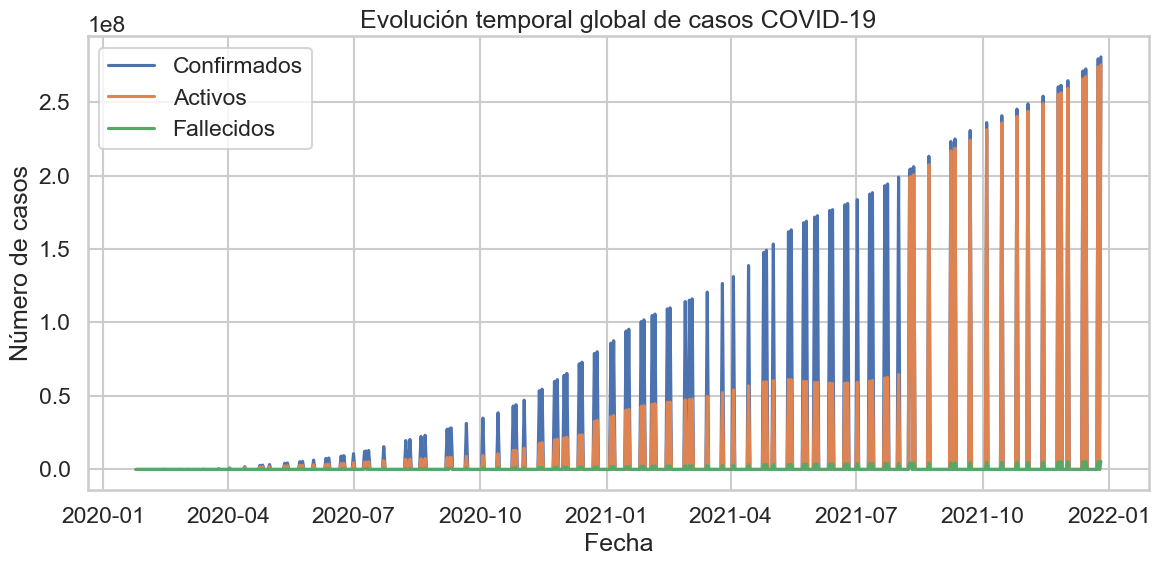

In [20]:
# 1) Evolución temporal global
time_series = df_plot.groupby(pd.Grouper(key='report_date', freq='D')).agg({
    'confirmed':'sum','active':'sum','deaths':'sum'
}).reset_index().sort_values('report_date')

plt.figure(figsize=(12,6))
plt.plot(time_series['report_date'], time_series['confirmed'], label='Confirmados')
plt.plot(time_series['report_date'], time_series['active'], label='Activos')
plt.plot(time_series['report_date'], time_series['deaths'], label='Fallecidos')
plt.xlabel('Fecha')
plt.ylabel('Número de casos')
plt.title('Evolución temporal global de casos COVID-19')
plt.legend()
plt.tight_layout()
plt.show()

# Preparar datos de la última fecha disponible
latest_date = df_plot['report_date'].max()
latest_data = df_plot[df_plot['report_date'] == latest_date].copy()


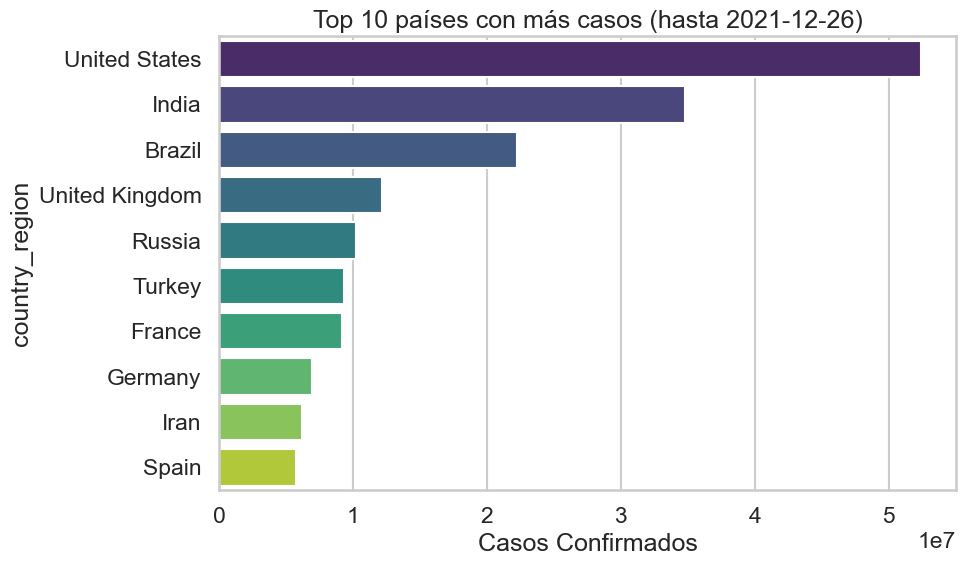

In [22]:
# 2) Top 10 países por confirmados (usa country_region normalizado)
top10 = latest_data.groupby('country_region', dropna=False)['confirmed'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='confirmed', y='country_region', hue='country_region', palette='viridis', legend=False)
plt.xlabel('Casos Confirmados')
plt.title(f'Top 10 países con más casos (hasta {latest_date.date()})')
plt.tight_layout()
plt.show()

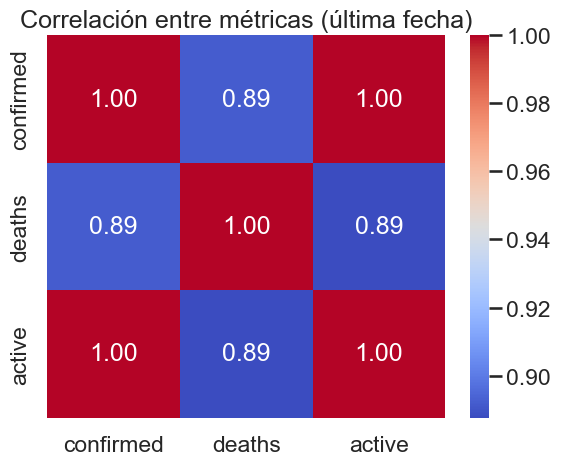

In [12]:
# 3) Heatmap de correlaciones (última fecha)
corr_cols = ['confirmed','deaths','active']
corr_data = latest_data[corr_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre métricas (última fecha)')
plt.tight_layout()
plt.show()


Diamond Princess not found in regex
MS Zaandam not found in regex
Summer Olympics 2020 not found in regex
Winter Olympics 2022 not found in regex
C:\Users\rodri\AppData\Local\Temp\ipykernel_13112\1414400334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=letalidad.sort_values('letalidad_pct', ascending=False),


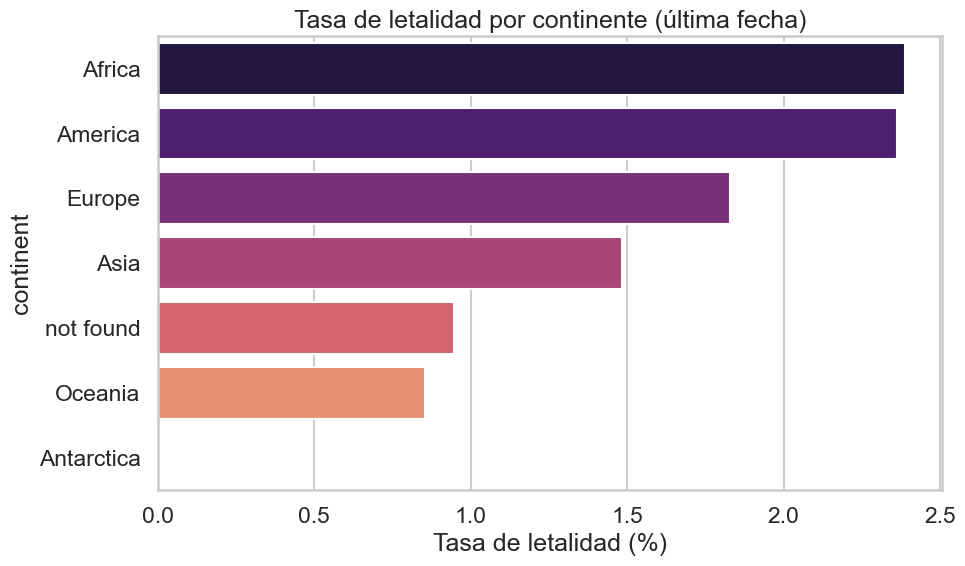

In [ ]:
# 4) Letalidad por continente (intenta resolver continente, si no, marca Unknown)
if 'continent' not in latest_data.columns:
    try:
        import country_converter as coco
        cc = coco.CountryConverter()
        latest_data['continent'] = cc.convert(names=latest_data['country_region'].fillna(''), to='continent')
    except Exception:
        latest_data['continent'] = 'Unknown'

letalidad = latest_data.groupby('continent')[['deaths','confirmed']].sum().reset_index()
letalidad['letalidad_pct'] = np.where(letalidad['confirmed']>0,
                                      letalidad['deaths']/letalidad['confirmed']*100, 0.0)

plt.figure(figsize=(10,6))
sns.barplot(data=letalidad.sort_values('letalidad_pct', ascending=False),
            x='letalidad_pct', y='continent', palette='magma')
plt.xlabel('Tasa de letalidad (%)')
plt.title('Tasa de letalidad por continente (última fecha)')
plt.tight_layout()
plt.show()

✓ Mapa cargado desde naturalearth CDN


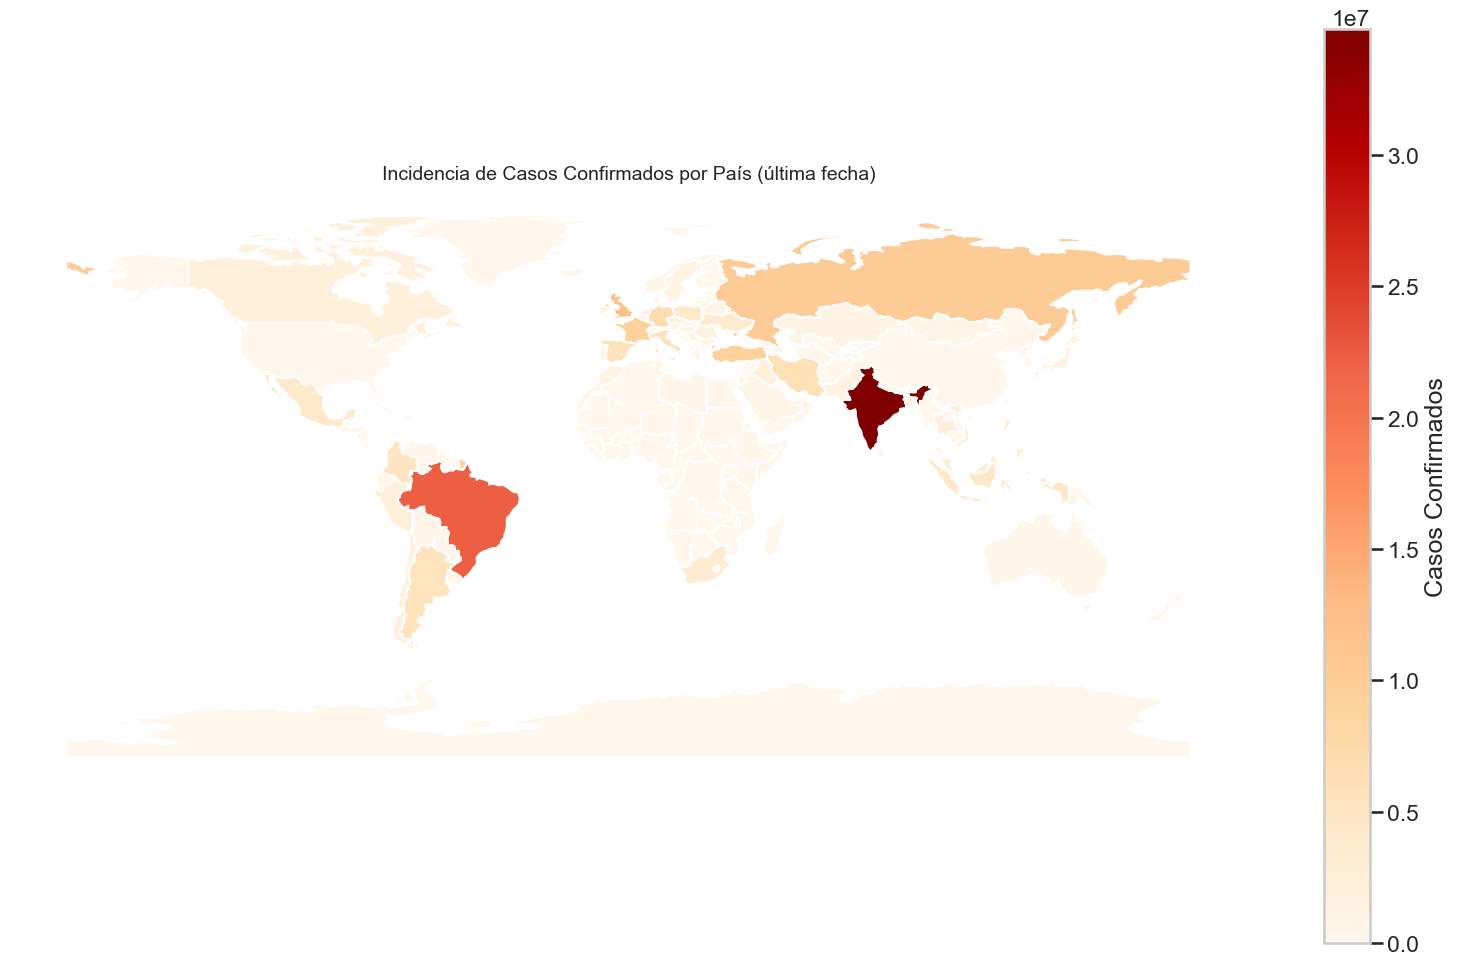

In [16]:
# 5) Mapa por país (si geopandas disponible) - con múltiples fallbacks
try:
    import geopandas as gpd
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    world = None
    
    # Intento 1: natural earth local (geopandas < 1.0)
    try:
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        print("✓ Mapa cargado desde geopandas.datasets")
    except Exception:
        pass
    
    # Intento 2: geodatasets (geopandas >= 1.0)
    if world is None:
        try:
            import geodatasets
            world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
            print("✓ Mapa cargado desde geodatasets")
        except Exception:
            pass
    
    # Intento 3: GeoJSON con reintentos locales
    if world is None:
        try:
            import requests
            from requests.adapters import HTTPAdapter
            from urllib3.util.retry import Retry
            
            session = requests.Session()
            retries = Retry(total=3, backoff_factor=1.0, status_forcelist=[429,500,502,503,504])
            session.mount("https://", HTTPAdapter(max_retries=retries))
            
            geojson_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
            response = session.get(geojson_url, timeout=20)
            if response.status_code == 200:
                from io import BytesIO
                world = gpd.read_file(BytesIO(response.content))
                print("✓ Mapa cargado desde naturalearth CDN")
        except Exception as e:
            print(f"  (intento 3 falló: {e})")
    
    # Si se cargó el mapa, graficar
    if world is not None:
        country_data = latest_data.groupby('country_region', dropna=False)['confirmed'].sum().reset_index()
        
        # Normalizar nombres de país en world
        if 'NAME' in world.columns:
            world_col = 'NAME'
        elif 'name' in world.columns:
            world_col = 'name'
        elif 'ADMIN' in world.columns:
            world_col = 'ADMIN'
        else:
            world_col = world.columns[0]
        
        # Merge con reintentos de emparejado
        merged = world.merge(country_data, how='left', left_on=world_col, right_on='country_region')
        merged['confirmed'] = merged['confirmed'].fillna(0)
        
        fig, ax = plt.subplots(figsize=(16,10))
        merged.plot(column='confirmed', ax=ax, cmap='OrRd', legend=True,
                   legend_kwds={'label': "Casos Confirmados", 'orientation': "vertical"},
                   missing_kwds={"color": "lightgrey"})
        ax.set_title('Incidencia de Casos Confirmados por País (última fecha)', fontsize=14)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ No se pudo cargar mapa geográfico. Mostrando tabla alternativa...")
        # Mostrar tabla en lugar del mapa
        country_summary = latest_data.groupby('country_region', dropna=False).agg({
            'confirmed': 'sum',
            'deaths': 'sum',
            'recovered': 'sum'
        }).sort_values('confirmed', ascending=False).head(20)
        print("\nTop 20 Países:")
        print(country_summary)
        
except ImportError:
    print("⚠ geopandas no está instalado. Omitiendo mapa.")
except Exception as e:
    print(f"⚠ Error en mapa: {e}")
    # Fallback: tabla de datos
    country_summary = latest_data.groupby('country_region', dropna=False).agg({
        'confirmed': 'sum',
        'deaths': 'sum',
        'recovered': 'sum'
    }).sort_values('confirmed', ascending=False).head(20)
    print("\nTop 20 Países (fallback):")
    print(country_summary)